## Descripcion de proyecto:

#### El proyecto tienen como objetivo analizar la información disponible acerca del manejo y trazabilidad de los RSU en México

## Objetivos:

#### 1.- Identificar la cantidad de generación total de RSU en México y por Estado y analizar la tendencia de los últimos años.
#### 2.- Identificar la cantidad  de RSU recolectados en México y por Estado
#### 3.- Identificar el número de servicios de recolección y tipo de sector (público, privado) por Estado y cobertura.
#### 4.- Existencia de programas en materia de gestión de residuos por Estado.
#### 5.- Identificar acciones que pudieran dar lugar a separación de residuos  (Estaciones de transferencia)
#### 6.- Identificar acciones que pudieran dar lugar a separación de residuos  (Plantas de Tratamiento)
#### 7.- Cantidad de RSU que se envian a sitios de disposición final.
#### 8.- Número de sitios de disposición del tipo rellenos sanitarios y tiraderos.

## CONCLUSIONES:

### No existe información disponible acerca de la generación de RSU por Entidad.

### Existe una relación entre número de municipios de cada Estado con la cantidad de servicios de recolección, Estados con mayor número de municipios mayor número de servicios de recolección.

### Existe una relación entre la actividad economica y la cantidad promedio recolectada al día. Estados con mayor aportación al PIB presentan mayor cantidad de RSU recolectados. Los estados que más cantidad de RSU recolectan son la Ciudad de México, México, Jalisco, Nuevo León, Puebla, Veracruz, Guanajuato y coincide con los estados que más aportan al PIB, lo cual quiere decir que existe más una relación de la cantidad de recolección de RSU con las actividades economicas que con la densidad poblacional.

### No existe relación entre número de municipios y cantidad recolectada de RSU.

### En méxico más del 93% de los residuos van directo a disposición final.

### únicamente 11 Estados cuentancon estaciones de transferencia.

### 19 Estados cuentan con plantas de tratamiento de RSU.


In [592]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats as st
import seaborn as sns
import numpy as np

### Leer archivos

In [ ]:
#municipios con servicios de recolección 2020,2022 y 2024:
df = pd.read_excel("concentrado2021_2025.xlsx")

#RSU recolectados por día por municipio 2020,2022 y 2024:
df_recolectados = pd.read_excel("concentrado_2021_2025_promedio_recolectados.xlsx", engine="openpyxl", na_values=["NA","ND", " ",""])

# Prestadores de servicios por municipios 2020,2022 y 2024:
prestadores_s=pd.read_excel("concentrado prestadores servicios.xlsx", engine="openpyxl", na_values=["NA","ND", " ",""])

# Densidad Poblacional
dp=pd.read_excel("densidad_poblacional.xlsx")

#% aportación al PIB

pib=pd.read_excel("PIB.xlsx")

# municipios con implementación de programas de manejo de residuos
programas=pd.read_excel("programas_2025.xlsx", engine="openpyxl", na_values=["NA","ND", " ",""])


#promedio diario de RSU enviado a Estaciones de Transferencia por Estado 2022
et=pd.read_excel("Estaciones_trasnferencia_2022.xlsx", engine="openpyxl", na_values=["NA","ND", "NSS" " ",""])

# promediodiariode RSU enviados a Plantas de tratamiento 2022

pt=pd.read_excel("Plantas_tratamiento_2022.xlsx", engine="openpyxl", na_values=["NA","ND", " ",""])



#sitios de disposición final 2022
sdf=pd.read_excel("sitios_disposición_final_2022.xlsx", engine="openpyxl", na_values=["NA","ND", " ",""])


## 1.-Municipios con servicios de Recolección de RSU 2020,2022,2024 (publicados y etiquetados como 2021,2023,2025)

### Explorar datos y limpieza

In [594]:
# Quitar saltos de línea y espacios extra
df.columns = df.columns.str.replace("\n", " ", regex=True).str.strip()

In [595]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7423 entries, 0 to 7422
Data columns (total 7 columns):
 #   Column                                                   Non-Null Count  Dtype
---  ------                                                   --------------  -----
 0   Entidad Federativa                                       7422 non-null   str  
 1   Municipio/ Demarcación territorial                       7423 non-null   str  
 2   Total                                                    7423 non-null   int64
 3   Con servicio de recolección de residuos sólidos urbanos  7423 non-null   int64
 4   Sin servicio de recolección de residuos sólidos urbanos  7423 non-null   int64
 5   No  especificado                                         7423 non-null   int64
 6   año                                                      7423 non-null   int64
dtypes: int64(5), str(2)
memory usage: 406.1 KB


In [596]:
#renombrar columnas
df = df.rename(columns={
    "Municipio/ Demarcación territorial": "municipio",
    "Total": "total_municipios",
    "Con servicio de recolección de residuos sólidos urbanos":"municipios_con_servicio_rrsu",
    "Sin servicio de recolección de residuos sólidos urbanos": "municipios_sinj_servicio_rrsu"})

In [597]:
df.sample(5)

,Entidad Federativa,municipio,total_municipios,municipios_con_servicio_rrsu,municipios_sinj_servicio_rrsu,No especificado,año
1815,Quintana Roo,Cozumel,1,1,0,0,2021
7177,Veracruz de Ignacio de la Llave,Poza Rica de Hidalgo,1,1,0,0,2025
308,Durango,Otáez,1,1,0,0,2021
5036,Chiapas,Ángel Albino Corzo,1,1,0,0,2025
4662,Veracruz de Ignacio de la Llave,Juan Rodríguez Clara,1,1,0,0,2023


In [598]:
df.isnull().sum()

Entidad Federativa               1
municipio                        0
total_municipios                 0
municipios_con_servicio_rrsu     0
municipios_sinj_servicio_rrsu    0
No  especificado                 0
año                              0
dtype: int64

In [599]:
#Con recolección
con_s_recoleccion=df.groupby(["Entidad Federativa","año"])["municipios_con_servicio_rrsu"].sum().reset_index()
print(con_s_recoleccion)

#sin recolección
sin_s_recoleccion=df.groupby(["Entidad Federativa","año"])["municipios_sinj_servicio_rrsu"].sum().reset_index()
print(sin_s_recoleccion)

   Entidad Federativa   año  municipios_con_servicio_rrsu
0      Aguascalientes  2021                            11
1      Aguascalientes  2023                            11
2      Aguascalientes  2025                            11
3     Baja California  2021                             6
4     Baja California  2023                             7
..                ...   ...                           ...
91            Yucatán  2023                           104
92            Yucatán  2025                           106
93          Zacatecas  2021                            57
94          Zacatecas  2023                            58
95          Zacatecas  2025                            57

[96 rows x 3 columns]
   Entidad Federativa   año  municipios_sinj_servicio_rrsu
0      Aguascalientes  2021                              0
1      Aguascalientes  2023                              0
2      Aguascalientes  2025                              0
3     Baja California  2021                  

In [600]:
#Generar tablas para determianr por entidad y año la cantidiad de municipios con servicios de recoleccion de RSU

con_s_recoleccion_tabla = (
    df.groupby(["Entidad Federativa", "año"])["municipios_con_servicio_rrsu"]
      .sum()
      .unstack(fill_value=0)   # convierte los años en columnas
)

print(con_s_recoleccion_tabla)
print()
sin_s_recoleccion_tabla = (
    df.groupby(["Entidad Federativa", "año"])["municipios_sinj_servicio_rrsu"]
      .sum()
      .unstack(fill_value=0)   # convierte los años en columnas
)

#print(sin_s_recoleccion_tabla)


año                              2021  2023  2025
Entidad Federativa                               
Aguascalientes                     11    11    11
Baja California                     6     7     7
Baja California Sur                 5     5     5
Campeche                           11    13    13
Chiapas                           122   122   120
Chihuahua                          67    67    67
Ciudad de México                   16    16    16
Coahuila de Zaragoza               38    38    38
Colima                             10    10    10
Durango                            39    39    39
Guanajuato                         46    46    46
Guerrero                           81    80    80
Hidalgo                            82    82    82
Jalisco                           125   125   124
Michoacán de Ocampo               113   113   113
Morelos                            36    36    36
México                            125   125   125
Nayarit                            20    20    20


### En realidad no hay mucho cambio en cuanto al número de municipios con servicios de recolección

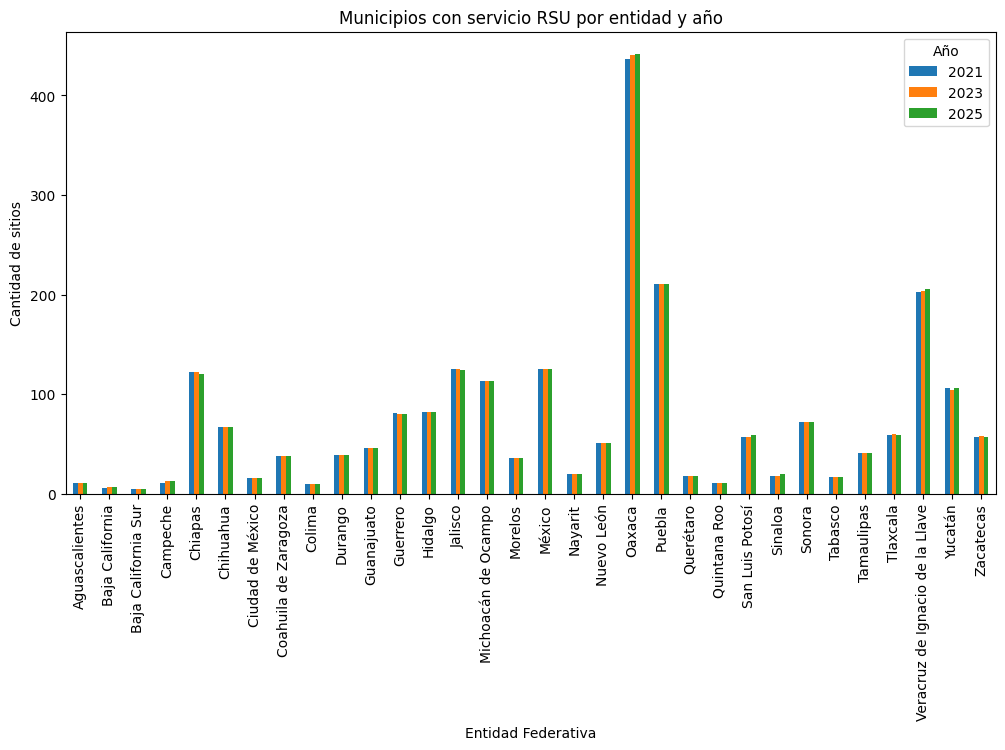

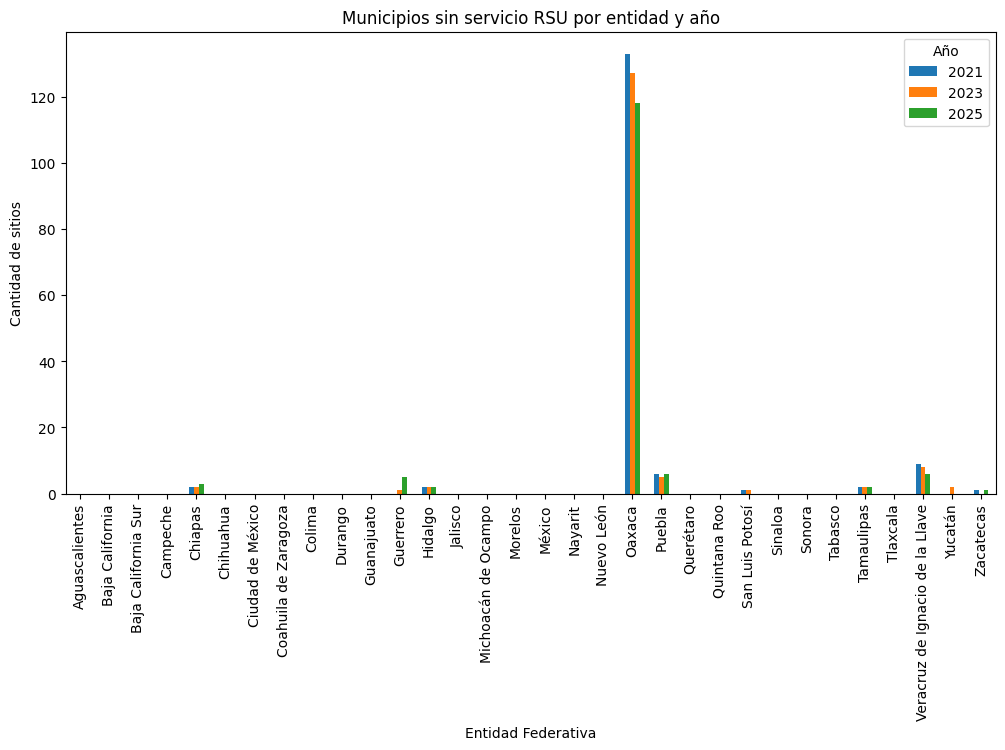

In [601]:
#graficar por estado la cantidad de municipios con servicio de recolección, por año
figura= con_s_recoleccion_tabla.plot(
    kind="bar",
    figsize=(12,6),
    title="Municipios con servicio RSU por entidad y año"
)

plt.xlabel("Entidad Federativa")
plt.ylabel("Cantidad de sitios")
plt.legend(title="Año")



plt.show()
sin_s_recoleccion_tabla.plot(
    kind="bar",
    figsize=(12,6),
    title="Municipios sin servicio RSU por entidad y año"
)

plt.xlabel("Entidad Federativa")
plt.ylabel("Cantidad de sitios")
plt.legend(title="Año")
plt.show()


#### Oaxaca (437), Veracruz (206), Puebla (211), Chiapas (120), son los estados con mayor cantidad de servicios de recolección, cifra que coincide con los estados con mayor cantidad de municipios registrados: 570,212, 217, 124, respectivamente. Podría decirse que existe casi un servicio de recolección por municipio: estados con más municipios tendrán mayor numero de servicios de recolección.

#### Como cabe la posibilidad de que no todos los municipios cuenten con un servicio de recolección, es importante determianar por Estado el % de cobertura de servicio de recolección en municipios


## % de Cobertura de servicio de recolección en municipios por Estado

In [602]:
#determinar municipios por estados y cobertura de servicio de recolección para 2024 (etiquetado como 2025):

a_2025=df[df["año"]==2025]

                               
municipios_total=a_2025.groupby("Entidad Federativa")["total_municipios"].sum().reset_index()
#print(recoleccion_2025)

municipios_con=a_2025.groupby("Entidad Federativa")["municipios_con_servicio_rrsu"].sum().reset_index()
#print(municipios_con)


cobertura_2025=municipios_total.merge(municipios_con, on="Entidad Federativa")

cobertura_2025["cobertura"]=(cobertura_2025["municipios_con_servicio_rrsu"]/cobertura_2025["total_municipios"])*100

print(cobertura_2025.sample(3))

     Entidad Federativa  total_municipios  municipios_con_servicio_rrsu  \
23      San Luis Potosí                59                            59   
25               Sonora                72                            72   
14  Michoacán de Ocampo               113                           113   

    cobertura  
23      100.0  
25      100.0  
14      100.0  


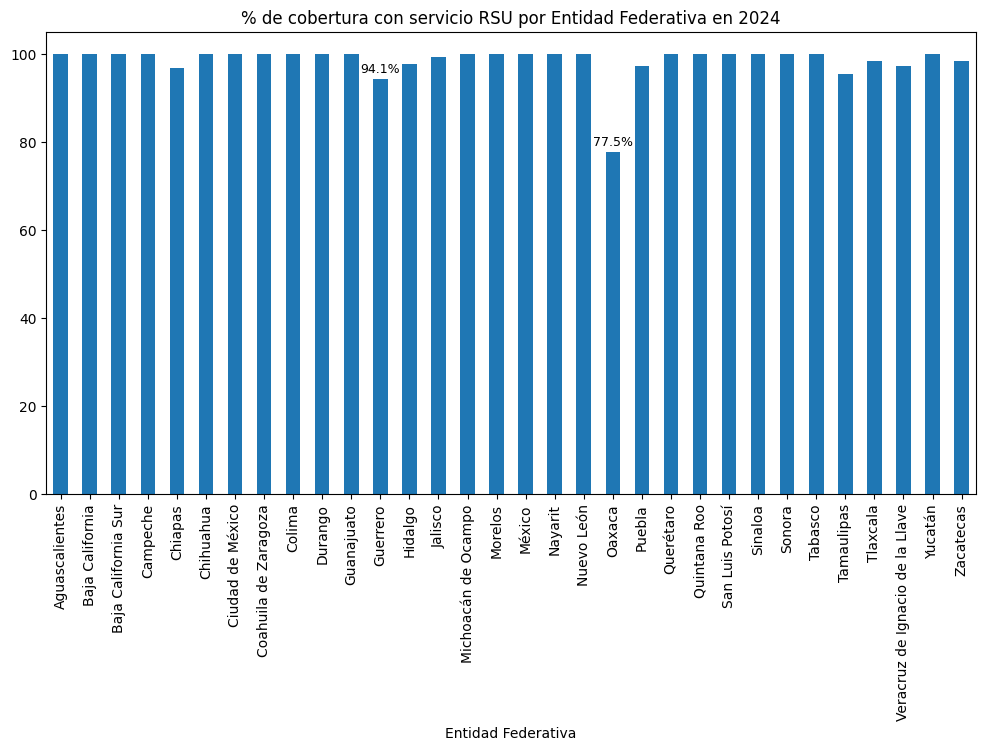

In [603]:
gráfico=cobertura_2025.plot(kind="bar",
    figsize=(12,6),
    title="% de cobertura con servicio RSU por Entidad Federativa en 2024",
    x="Entidad Federativa",
    y="cobertura",
    legend=False   
)


for p in gráfico.patches:
    if p.get_height() <95:   # solo si la cobertura es mayor a 80%
        gráfico.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha="center", va="bottom", fontsize=9, color="black", xytext=(0,3),
            textcoords="offset points"
    )

plt.show()


#### Oaxaca y Guerrero son los Estados que presentan una cobertura de recolección por debajo del 95% para sus municipios.

# 2.-Promedio diario de RSU recolectados

In [604]:
df_recolectados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 4 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Entidad Federativa                                                 7422 non-null   str    
 1   Municipio/Demarcación territorial                                  7422 non-null   str    
 2   Cantidad promedio diaria de residuos sólidos urbanos recolectados  6951 non-null   float64
 3   año                                                                7422 non-null   int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 232.1 KB


In [605]:
df_recolectados.sample(3)

,Entidad Federativa,Municipio/Demarcación territorial,Cantidad promedio diaria de residuos sólidos urbanos recolectados,año
30,Campeche,Escárcega,33000.0,2021
6092,Oaxaca,San Felipe Jalapa de Díaz,16000.0,2025
1336,Oaxaca,San Pedro Taviche,172.0,2021


In [606]:
df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].unique()

array([697540.,  25800.,  65000., ..., 175000.,  13800.,  96560.],
      shape=(1499,))

In [607]:
df_recolectados.isnull().sum()

Entidad Federativa                                                     0
Municipio/Demarcación territorial                                      0
Cantidad promedio diaria de residuos sólidos urbanos recolectados    471
año                                                                    0
dtype: int64

In [608]:
df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].isnull().sum()

np.int64(471)

In [609]:
#eliminar filas donde existan valores nulos en la oclumna "Cantidad promedio diaria de residuos sólidos urbanos recolectados"

df_recolectados = df_recolectados.dropna(subset=["Cantidad promedio diaria de residuos sólidos urbanos recolectados"])


In [610]:
df_recolectados.info()

<class 'pandas.DataFrame'>
Index: 6951 entries, 0 to 7421
Data columns (total 4 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Entidad Federativa                                                 6951 non-null   str    
 1   Municipio/Demarcación territorial                                  6951 non-null   str    
 2   Cantidad promedio diaria de residuos sólidos urbanos recolectados  6951 non-null   float64
 3   año                                                                6951 non-null   int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 271.5 KB


In [611]:
df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"]=df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].astype(int)

In [612]:
# conversión a millones de toneladas

df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"]=df_recolectados["Cantidad promedio diaria de residuos sólidos urbanos recolectados"]/1000000

In [613]:
total_rsu_reco_día=df_recolectados.groupby(["Entidad Federativa","año"])["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].sum().reset_index()
print(total_rsu_reco_día)

   Entidad Federativa   año  \
0      Aguascalientes  2021   
1      Aguascalientes  2023   
2      Aguascalientes  2025   
3     Baja California  2021   
4     Baja California  2023   
..                ...   ...   
91            Yucatán  2023   
92            Yucatán  2025   
93          Zacatecas  2021   
94          Zacatecas  2023   
95          Zacatecas  2025   

    Cantidad promedio diaria de residuos sólidos urbanos recolectados  
0                                            1.022718                  
1                                            1.268552                  
2                                            1.370347                  
3                                            3.264039                  
4                                            3.365791                  
..                                                ...                  
91                                           1.886875                  
92                                           1.9972

In [614]:
total_rsu_reco_día_tabla = total_rsu_reco_día.groupby(["Entidad Federativa","año"])["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].sum().unstack(fill_value=0)   

print(total_rsu_reco_día_tabla)



año                                   2021       2023       2025
Entidad Federativa                                              
Aguascalientes                    1.022718   1.268552   1.370347
Baja California                   3.264039   3.365791   3.484227
Baja California Sur               1.105823   0.920730   0.959510
Campeche                          0.601994   0.740250   0.814000
Chiapas                           3.186689   3.263688   3.531631
Chihuahua                         4.054478   3.354934   3.649493
Ciudad de México                 14.964226  15.557424  16.153776
Coahuila de Zaragoza              2.628920   2.612453   2.534965
Colima                            0.780735   0.824523   0.868483
Durango                           1.331401   1.401209   1.498331
Guanajuato                        4.561632   4.549696   4.733707
Guerrero                          2.396239   2.739421   2.854321
Hidalgo                           1.941384   1.815923   1.852131
Jalisco                  

In [615]:
totales=df_recolectados.groupby("año")["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].sum().reset_index()
totales["Cantidad promedio diaria de residuos sólidos urbanos recolectados"]
print(totales)


    año  Cantidad promedio diaria de residuos sólidos urbanos recolectados
0  2021                                         106.523136                
1  2023                                         108.146271                
2  2025                                         114.318730                


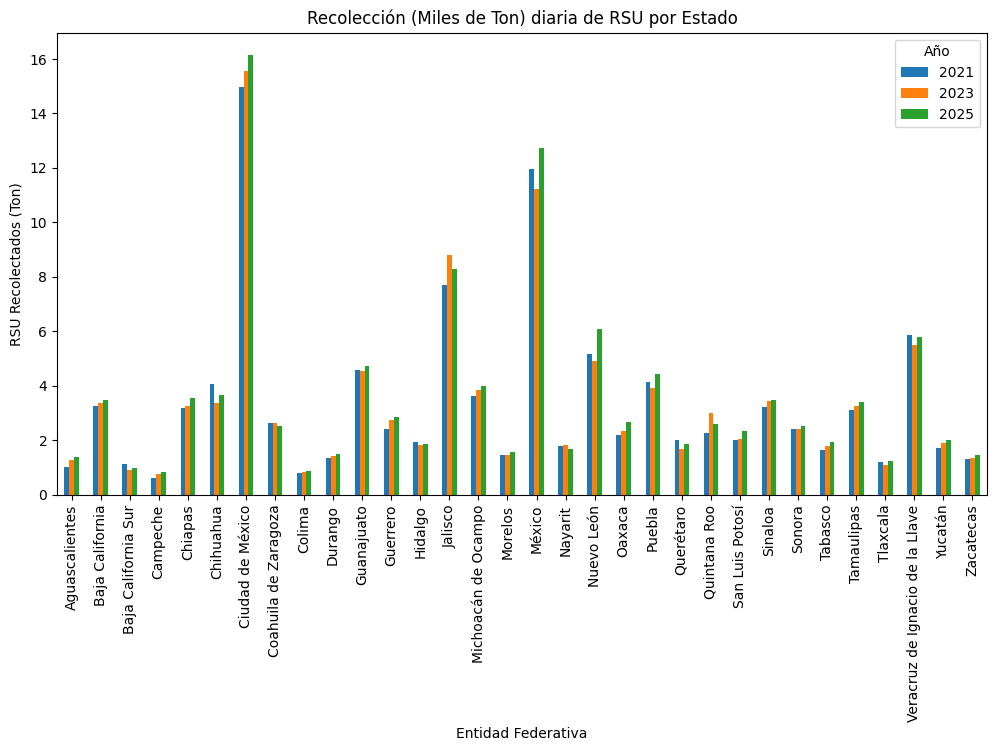

In [616]:
total_rsu_reco_día_tabla.plot(
    kind="bar",
    figsize=(12,6),
    title="Recolección (Miles de Ton) diaria de RSU por Estado"
)

plt.xlabel("Entidad Federativa")
plt.ylabel("RSU Recolectados (Ton)")
plt.legend(title="Año")
plt.show()


#### Aún cuanto Oaxaca y Chiapas sean los Estados con mayor numero de servicios de recolección, no son precisamente los Estados con mayor cantidad de RSU recolectados diariamente, esta tendencia podría estar marcada tanto por la población en cada Estado como por su actividad Económica.

#### Los Estados con mayor recolección diaria son la Ciudad de México, México, Jalisco, Nuevo León, Puebla, Veracruz, Guanajuato.




<Axes: xlabel='años', ylabel='toneladas'>

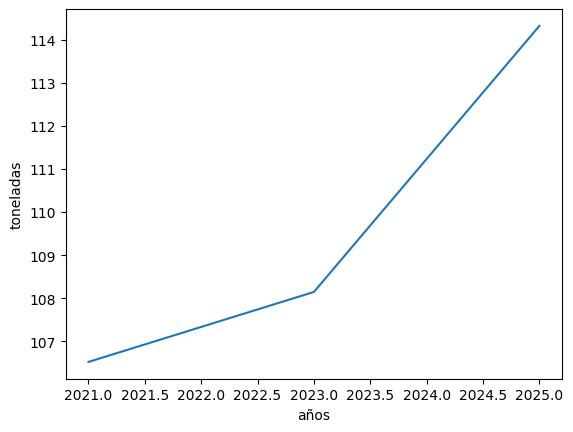

In [617]:
totales.plot(kind="line",
                     x="año",
                     y="Cantidad promedio diaria de residuos sólidos urbanos recolectados",
                     legend=False,
                     xlabel="años",
                     ylabel="toneladas"
                     )

In [618]:
df_recolectados.sample(3)

,Entidad Federativa,Municipio/Demarcación territorial,Cantidad promedio diaria de residuos sólidos urbanos recolectados,año
4871,Yucatán,Tixcacalcupul,0.0002,2023
2791,Durango,Santiago Papasquiaro,0.0400,2023
626,Jalisco,Tecolotlán,0.0200,2021


In [619]:
# filtras información únicamente para el año 2025
df2025=df_recolectados[df_recolectados["año"]==2025]

inf2025=df2025.groupby("Entidad Federativa")["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].sum().reset_index()
print(inf2025)



                 Entidad Federativa  \
0                    Aguascalientes   
1                   Baja California   
2               Baja California Sur   
3                          Campeche   
4                           Chiapas   
5                         Chihuahua   
6                  Ciudad de México   
7              Coahuila de Zaragoza   
8                            Colima   
9                           Durango   
10                       Guanajuato   
11                         Guerrero   
12                          Hidalgo   
13                          Jalisco   
14              Michoacán de Ocampo   
15                          Morelos   
16                           México   
17                          Nayarit   
18                       Nuevo León   
19                           Oaxaca   
20                           Puebla   
21                        Querétaro   
22                     Quintana Roo   
23                  San Luis Potosí   
24                       

## 3.-Prestadores de Servicio

In [620]:
prestadores_s.columns = prestadores_s.columns.str.replace("\n", " ", regex=True).str.strip()

In [621]:
prestadores_s.info()

<class 'pandas.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Entidad Federativa                  7422 non-null   str    
 1   Municipio/ Demarcación territorial  7422 non-null   str    
 2   Total                               6951 non-null   float64
 3   Sector público                      6951 non-null   float64
 4   Sector privado                      6951 non-null   float64
 5   Sector social                       6951 non-null   float64
 6   año                                 7422 non-null   int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 406.0 KB


In [622]:
prestadores_s.isnull().sum()

Entidad Federativa                      0
Municipio/ Demarcación territorial      0
Total                                 471
Sector público                        471
Sector privado                        471
Sector social                         471
año                                     0
dtype: int64

In [623]:
prestadores_s=prestadores_s.dropna()

In [624]:
prestadores_s.info()

<class 'pandas.DataFrame'>
Index: 6951 entries, 0 to 7421
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Entidad Federativa                  6951 non-null   str    
 1   Municipio/ Demarcación territorial  6951 non-null   str    
 2   Total                               6951 non-null   float64
 3   Sector público                      6951 non-null   float64
 4   Sector privado                      6951 non-null   float64
 5   Sector social                       6951 non-null   float64
 6   año                                 6951 non-null   int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 434.4 KB


In [625]:
columnas = ["Total", "Sector público", "Sector privado", "Sector social", "año"]

prestadores_s[columnas] = prestadores_s[columnas].astype(int)

In [626]:
prestadores_s.sample(3)

,Entidad Federativa,Municipio/ Demarcación territorial,Total,Sector público,Sector privado,Sector social,año
3725,Oaxaca,San Martín Peras,1,1,0,0,2023
1353,Oaxaca,San Sebastián Ixcapa,1,1,0,0,2021
4293,Quintana Roo,Benito Juárez,1,0,1,0,2023


In [627]:

a=prestadores_s.groupby(["Entidad Federativa", "año"])["Total"].sum()
print(a)


Entidad Federativa  año 
Aguascalientes      2021     11
                    2023     11
                    2025     11
Baja California     2021      9
                    2023      9
                           ... 
Yucatán             2023    117
                    2025    116
Zacatecas           2021     57
                    2023     58
                    2025     57
Name: Total, Length: 96, dtype: int64


In [628]:
reco_s_2025=prestadores_s[prestadores_s["año"]==2025]


In [629]:
prestadores_estado_2025=reco_s_2025.groupby("Entidad Federativa")["Total"].sum().reset_index()
print(prestadores_estado_2025)

                 Entidad Federativa  Total
0                    Aguascalientes     11
1                   Baja California      9
2               Baja California Sur      5
3                          Campeche     20
4                           Chiapas    123
5                         Chihuahua     84
6                  Ciudad de México     19
7              Coahuila de Zaragoza     42
8                            Colima     10
9                           Durango     44
10                       Guanajuato     56
11                         Guerrero     82
12                          Hidalgo    105
13                          Jalisco    139
14              Michoacán de Ocampo    139
15                          Morelos     44
16                           México    194
17                          Nayarit     31
18                       Nuevo León     52
19                           Oaxaca    469
20                           Puebla    212
21                        Querétaro     20
22         

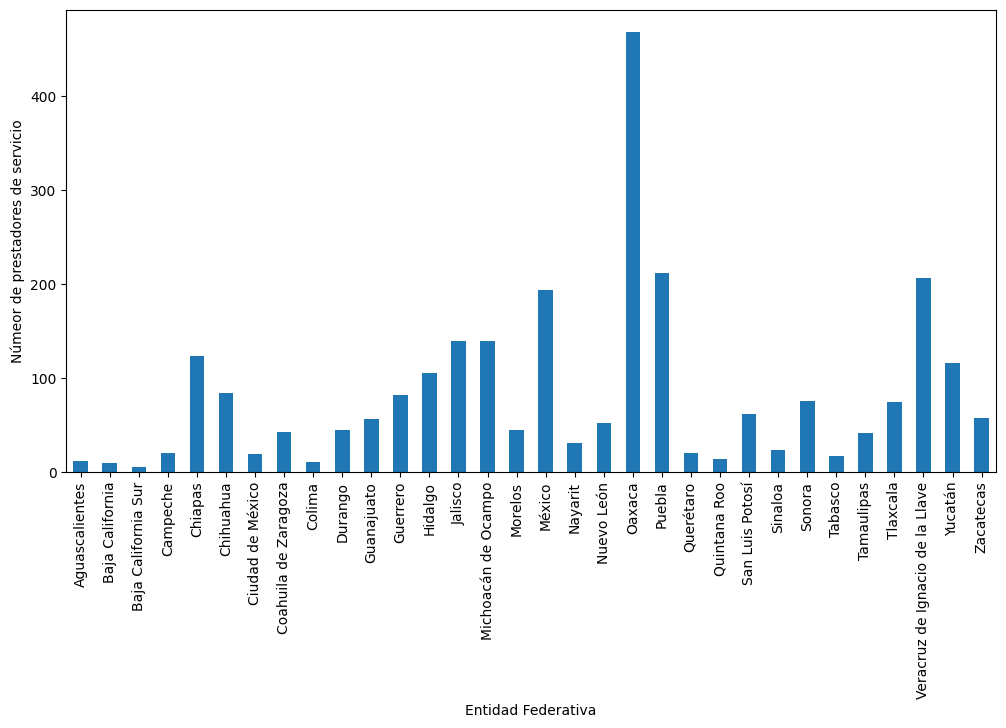

In [630]:
prestadores_estado_2025.plot(
    kind="bar",
    x="Entidad Federativa",
    y="Total",
    figsize=(12,6),
    legend=False,
    ylabel="Númeor de prestadores de servicio"
    
)

plt.show()

## 3.1 ¿Qué % del total son servicios públicos y privados?

In [631]:
prestadores_estado_2025=reco_s_2025.groupby("Entidad Federativa")["Total"].sum().reset_index()

prestadores_sp_estado_2025=reco_s_2025.groupby("Entidad Federativa")["Sector público"].sum().reset_index()

prestadores_spriv_estado_2025=reco_s_2025.groupby("Entidad Federativa")["Sector privado"].sum().reset_index()

prestadores_soc_estado_2025=reco_s_2025.groupby("Entidad Federativa")["Sector social"].sum().reset_index()


In [632]:
b = (
    prestadores_estado_2025
    .merge(prestadores_sp_estado_2025, on="Entidad Federativa")
    .merge(prestadores_spriv_estado_2025, on="Entidad Federativa")
    .merge(prestadores_soc_estado_2025, on="Entidad Federativa")
)

print(b.sample(3))

   Entidad Federativa  Total  Sector público  Sector privado  Sector social
0      Aguascalientes     11              11               0              0
4             Chiapas    123             121               2              0
10         Guanajuato     56              41              15              0


In [633]:
b["Sector_publico_%"]=(b["Sector público"]/b["Total"])*100
b["Sector_privado_%"]=(b["Sector privado"]/b["Total"])*100
b["Sector_social_%"]=(b["Sector social"]/b["Total"])*100

print(b.sample(3))

     Entidad Federativa  Total  Sector público  Sector privado  Sector social  \
14  Michoacán de Ocampo    139             111              19              9   
10           Guanajuato     56              41              15              0   
6      Ciudad de México     19              16               3              0   

    Sector_publico_%  Sector_privado_%  Sector_social_%  
14         79.856115         13.669065          6.47482  
10         73.214286         26.785714          0.00000  
6          84.210526         15.789474          0.00000  


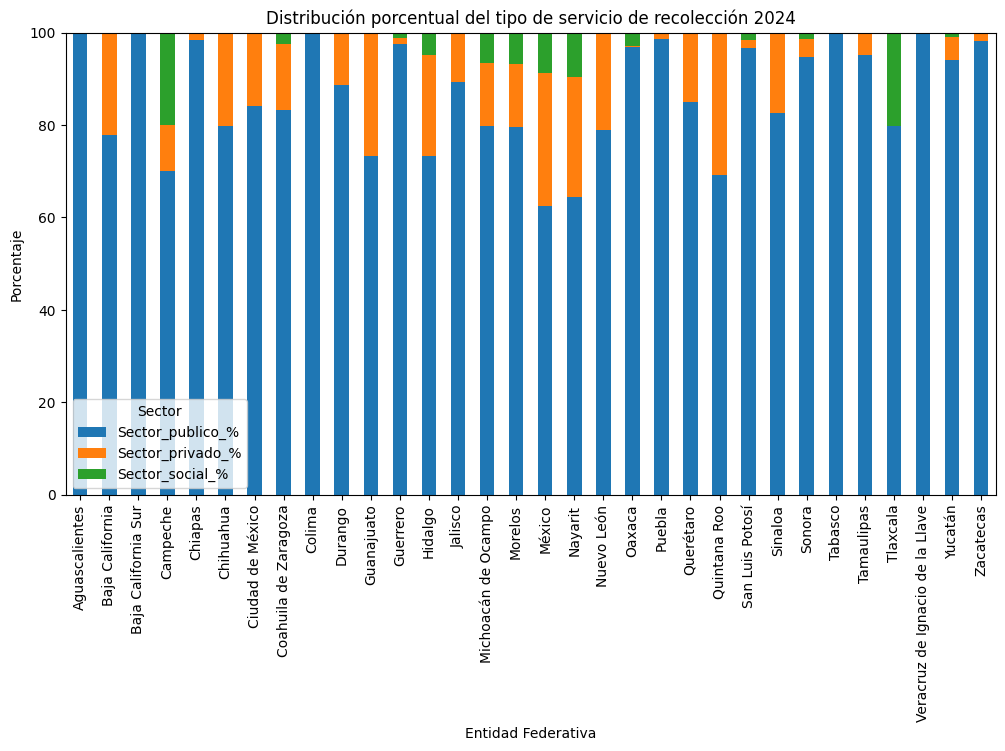

In [634]:
Y = ["Sector_publico_%", "Sector_privado_%", "Sector_social_%"]

gráfica = b.plot(
    kind="bar",
    x="Entidad Federativa",
    y=Y,
    stacked=True,            
    figsize=(12,6),
    title="Distribución porcentual del tipo de servicio de recolección 2024"
)

plt.ylabel("Porcentaje")
plt.xticks(rotation=90)
plt.legend(title="Sector")
plt.show()

### La mayoría de los prestadores de servicio de recoleccion de RSU provienen de sector público, estados como Aguascalientes, BCS, Colima, Tabasco y Veracruz es el sector público quien realiza la recolección de RSU.
### Por otro lado, en Campeche, Michoacán, Morelos, México, Nayarit, Tlaxcala resalta la participación del sector social.

### Dado que los estados con mayor número de servicios de recolección, no son precisamente los que más RSU recolectan, vale la pena relacionar la cantidad de RSU recolectados con la densidad poblacional o bien con la actividad economica a traves de PIB. 
### Por ello, sería interesante graficar recoleccción 2025, densidad poblacional 2020 y PIB 2021 para visualizar tendencias.

### 4.- Densidad poblacional 2020

In [635]:
dp.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entidad federativa         33 non-null     str    
 1   Densidad poblacional 2020  33 non-null     float64
dtypes: float64(1), str(1)
memory usage: 660.0 bytes


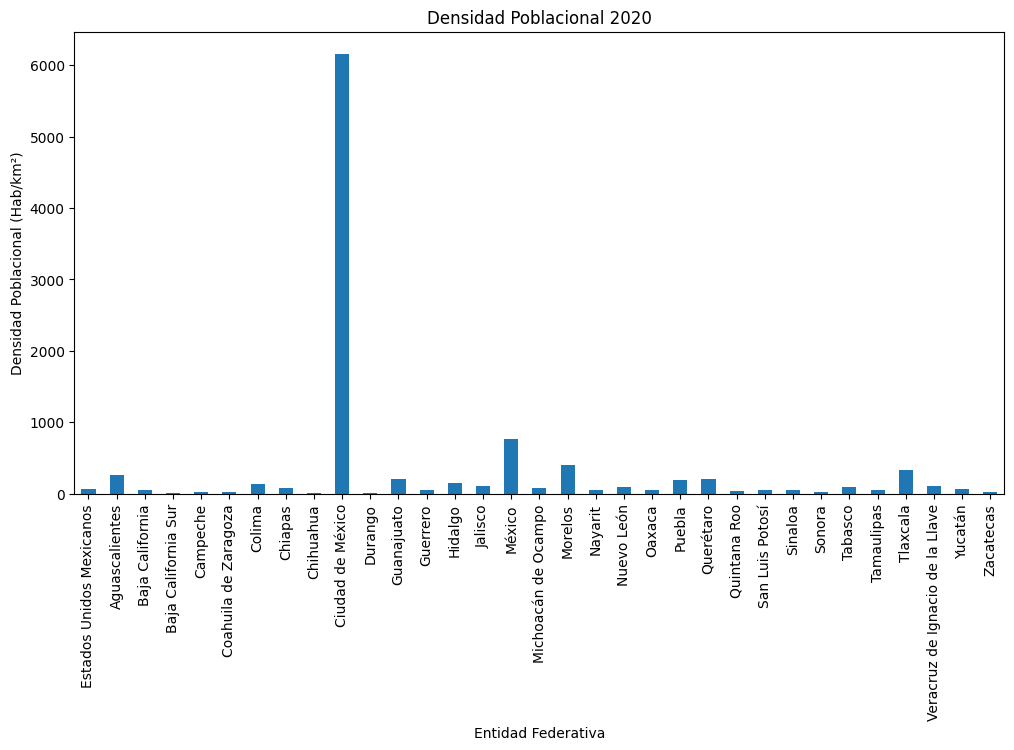

In [636]:
dp.plot(kind="bar",
        figsize=(12,6),
        x="Entidad federativa",
        y="Densidad poblacional 2020",
        title="Densidad Poblacional 2020",
        legend=False,
        )
plt.xlabel("Entidad Federativa")
plt.ylabel("Densidad Poblacional (Hab/km²)")
plt.show()





## 5.- PIB 2021

In [637]:
pib.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Estado                 32 non-null     str    
 1   % aportación PIB 2021  32 non-null     float64
dtypes: float64(1), str(1)
memory usage: 644.0 bytes


In [638]:

pib["Estado"] = pib["Estado"].str.strip()

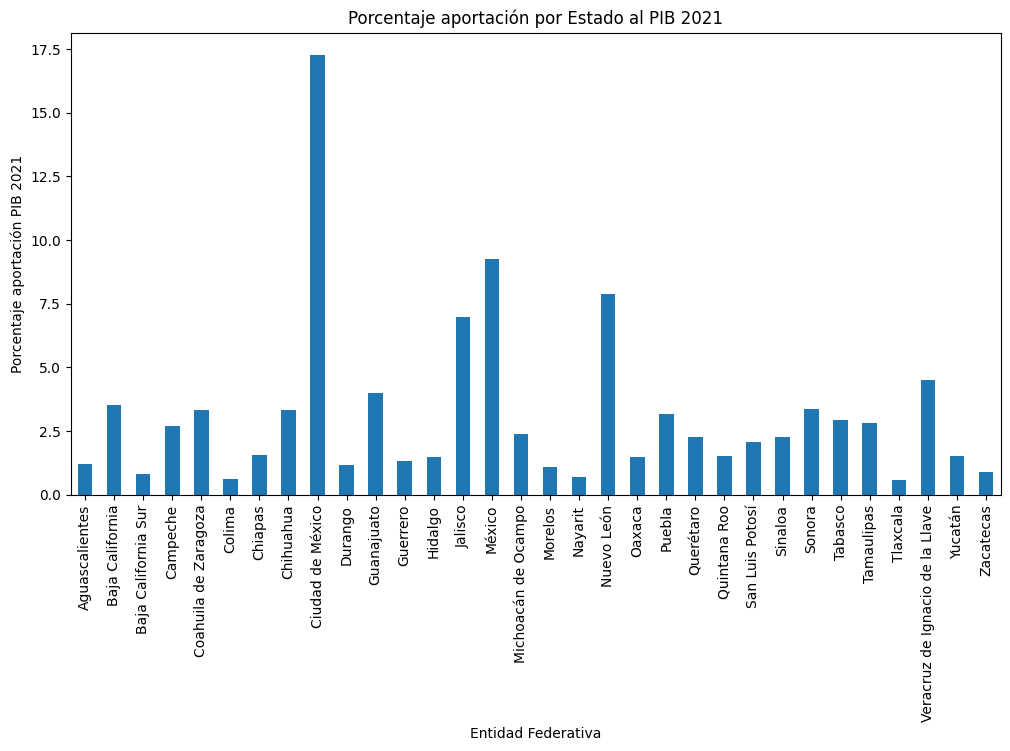

In [639]:
pib.plot(
    kind="bar",
    figsize=(12,6),
    x="Estado",
    y="% aportación PIB 2021",
    title="Porcentaje aportación por Estado al PIB 2021",
    legend=False,
        )

plt.xlabel("Entidad Federativa")
plt.ylabel("Porcentaje aportación PIB 2021")
plt.show()

    


In [640]:
total_rsu_reco_día_tabla.sample()

año,2021,2023,2025
Entidad Federativa,,,
Puebla,4.123024,3.926876,4.425009


In [641]:
#realizar graficos para tendencias: juntar df de residuos recolectados en 2025 y densidad poblacional por Estado
tendencias=pd.merge(inf2025, dp, left_on="Entidad Federativa", right_on="Entidad federativa")
tendencias=tendencias[["Entidad Federativa","Cantidad promedio diaria de residuos sólidos urbanos recolectados","Densidad poblacional 2020"]]


tendencias["Entidad Federativa"] = tendencias["Entidad Federativa"].str.strip()

In [642]:
#realizar merge con df de pib

tendencias=pd.merge(tendencias, pib, left_on="Entidad Federativa", right_on="Estado")
print(tendencias.sample(3))

                 Entidad Federativa  \
10                       Guanajuato   
29  Veracruz de Ignacio de la Llave   
2               Baja California Sur   

    Cantidad promedio diaria de residuos sólidos urbanos recolectados  \
10                                           4.733707                   
29                                           5.786309                   
2                                            0.959510                   

    Densidad poblacional 2020                           Estado  \
10                      201.5                       Guanajuato   
29                      112.3  Veracruz de Ignacio de la Llave   
2                        10.8              Baja California Sur   

    % aportación PIB 2021  
10               4.005426  
29               4.501068  
2                0.828464  


In [643]:
tendencias.sample(5)

,Entidad Federativa,Cantidad promedio diaria de residuos sólidos urbanos recolectados,Densidad poblacional 2020,Estado,% aportación PIB 2021
18,Nuevo León,6.084488,90.2,Nuevo León,7.892561
3,Campeche,0.814000,16.1,Campeche,2.713226
17,Nayarit,1.662313,44.4,Nayarit,0.681852
1,Baja California,3.484227,52.8,Baja California,3.516412
12,Hidalgo,1.852131,148.1,Hidalgo,1.475513


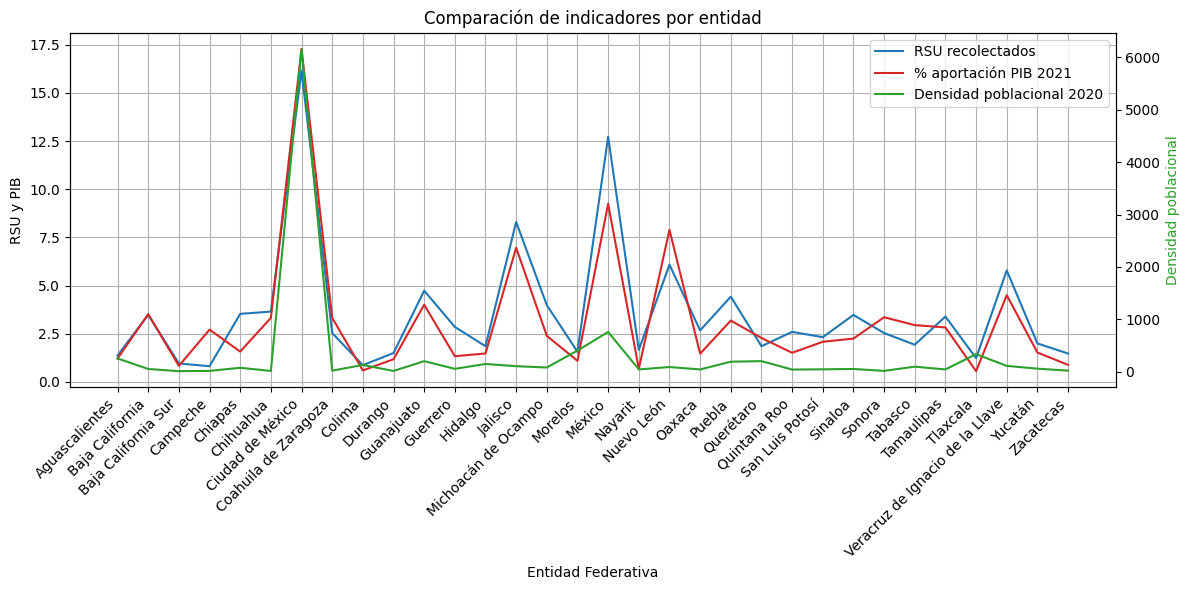

In [644]:


x = tendencias["Entidad Federativa"]

fig, ax1 = plt.subplots(figsize=(12,6))  # haz la figura más ancha

# Primer eje Y
ax1.plot(range(len(x)), tendencias["Cantidad promedio diaria de residuos sólidos urbanos recolectados"], 
         color="tab:blue", label="RSU recolectados")
ax1.plot(range(len(x)), tendencias["% aportación PIB 2021"], 
         color="tab:red", label="% aportación PIB 2021")
ax1.set_ylabel("RSU y PIB", color="black")
ax1.set_xlabel("Entidad Federativa")
ax1.grid(True)

# Segundo eje Y
ax2 = ax1.twinx()
ax2.plot(range(len(x)), tendencias["Densidad poblacional 2020"], 
         color="tab:green", label="Densidad poblacional 2020")
ax2.set_ylabel("Densidad poblacional", color="tab:green")

# 👉 Aquí está la modificación clave
ax1.set_xticks(range(len(x)))             # posiciones
ax1.set_xticklabels(x, rotation=45, ha="right")  # etiquetas con rotación

# Combinar leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Comparación de indicadores por entidad")
plt.tight_layout()
plt.show()







### Conclusiones:

los estados que más cantidad de RSU recolectan son la Ciudad de México, México, Jalisco, Nuevo León, Puebla, Veracruz, Guanajuato y coincide con los estados que más aportan al PIB, lo cual quiere decir que existe másuna relación de la cantidad de recolección de RSU con las actividades economicas que con la densidad poblacional.


### 6.- Existencia de Programa Municipal para la Prevención y Gestión Integral de los Residuos Sólidos Urbanos por Estado 2024

In [645]:
programas.columns = programas.columns.str.replace("\n", " ", regex=True).str.strip()

In [646]:
programas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 6 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Entidad federativa                                                                              2478 non-null   str    
 1   Municipio/ Demarcación territorial                                                              2478 non-null   str    
 2   Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos  2322 non-null   float64
 3   Tipo de programa PMPGIRSU 1                                                                     180 non-null    float64
 4   Tipo de programa Otro                                                                           180 non-null    float64
 5   Año de elaboración del PM

In [647]:
programas.isnull().sum()


Entidad federativa                                                                                   0
Municipio/ Demarcación territorial                                                                   0
Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos     156
Tipo de programa PMPGIRSU 1                                                                       2298
Tipo de programa Otro                                                                             2298
Año de elaboración del PMPGIRSU                                                                   2428
dtype: int64

In [648]:
nulos=programas["Tipo de programa PMPGIRSU 1"].isnull().sum()
print(nulos)

2298


In [649]:

programas = programas.dropna(subset=["Tipo de programa PMPGIRSU 1"])

In [650]:
programas.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 0 to 2475
Data columns (total 6 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Entidad federativa                                                                              180 non-null    str    
 1   Municipio/ Demarcación territorial                                                              180 non-null    str    
 2   Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos  180 non-null    float64
 3   Tipo de programa PMPGIRSU 1                                                                     180 non-null    float64
 4   Tipo de programa Otro                                                                           180 non-null    float64
 5   Año de elaboración del PMPGIRSU

In [651]:
programas.sample(3)

,Entidad federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,Año de elaboración del PMPGIRSU
278,Ciudad de México,Gustavo A. Madero,1.0,0.0,1.0,NaN
672,México,Aculco,1.0,1.0,0.0,2022.0
426,Guerrero,Quechultenango,1.0,0.0,1.0,NaN


In [652]:
programas.isnull().sum()

Entidad federativa                                                                                  0
Municipio/ Demarcación territorial                                                                  0
Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos      0
Tipo de programa PMPGIRSU 1                                                                         0
Tipo de programa Otro                                                                               0
Año de elaboración del PMPGIRSU                                                                   130
dtype: int64

In [653]:
programas["Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos"]= programas["Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos"].astype(int)

In [654]:
programas_estado=programas.groupby("Entidad federativa")["Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos"].sum().reset_index()
print(programas_estado)

                 Entidad federativa  \
0                    Aguascalientes   
1                   Baja California   
2               Baja California Sur   
3                          Campeche   
4                           Chiapas   
5                         Chihuahua   
6                  Ciudad de México   
7              Coahuila de Zaragoza   
8                        Guanajuato   
9                          Guerrero   
10                          Hidalgo   
11                          Jalisco   
12              Michoacán de Ocampo   
13                          Morelos   
14                           México   
15                          Nayarit   
16                       Nuevo León   
17                           Oaxaca   
18                           Puebla   
19                        Querétaro   
20                     Quintana Roo   
21                          Sinaloa   
22                           Sonora   
23                          Tabasco   
24                       

In [655]:
programas_estado.sample(29)

,Entidad federativa,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos
16,Nuevo León,4
7,Coahuila de Zaragoza,1
0,Aguascalientes,1
15,Nayarit,1
3,Campeche,1
22,Sonora,1
20,Quintana Roo,1
12,Michoacán de Ocampo,5
28,Zacatecas,1
2,Baja California Sur,4


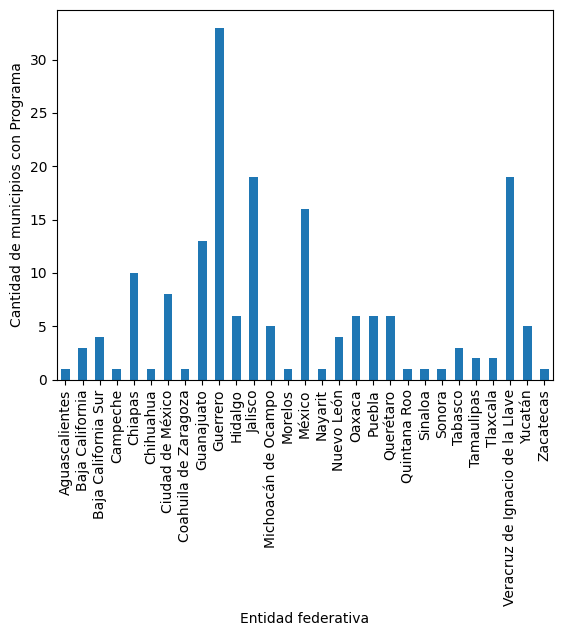

In [656]:
programas_estado.plot(
    kind="bar",
    x="Entidad federativa",
    y="Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos",
    legend=False,
    ylabel="Cantidad de municipios con Programa"

)
plt.show()

In [657]:
programas.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 0 to 2475
Data columns (total 6 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Entidad federativa                                                                              180 non-null    str    
 1   Municipio/ Demarcación territorial                                                              180 non-null    str    
 2   Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos  180 non-null    int64  
 3   Tipo de programa PMPGIRSU 1                                                                     180 non-null    float64
 4   Tipo de programa Otro                                                                           180 non-null    float64
 5   Año de elaboración del PMPGIRSU

In [658]:
# determinar por Estado % de municipios que tienen programas 

programas = programas.rename(columns={"Entidad federativa": "Entidad Federativa"})
programas.sample(3)

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,Año de elaboración del PMPGIRSU
1545,Oaxaca,Santo Tomás Mazaltepec,1,0.0,1.0,NaN
1451,Oaxaca,Santa María Tlahuitoltepec,1,0.0,1.0,NaN
1939,Sonora,Hermosillo,1,0.0,1.0,NaN


In [659]:

print(municipios_total)

                 Entidad Federativa  total_municipios
0                    Aguascalientes                11
1                   Baja California                 7
2               Baja California Sur                 5
3                          Campeche                13
4                           Chiapas               124
5                         Chihuahua                67
6                  Ciudad de México                16
7              Coahuila de Zaragoza                38
8                            Colima                10
9                           Durango                39
10                       Guanajuato                46
11                         Guerrero                85
12                          Hidalgo                84
13                          Jalisco               125
14              Michoacán de Ocampo               113
15                          Morelos                36
16                           México               125
17                          

In [660]:
porcentaje=programas.merge(municipios_total, on="Entidad Federativa")
porcentaje.sample()

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,Año de elaboración del PMPGIRSU,total_municipios
2,Baja California,Playas de Rosarito,1,0.0,1.0,NaN,7


In [661]:

porcentaje = porcentaje.drop(columns=["Año de elaboración del PMPGIRSU"])

porcentaje.sample(10)

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,total_municipios
81,Jalisco,Autlán de Navarro,1,1.0,0.0,125
158,Veracruz de Ignacio de la Llave,Cosoleacaque,1,1.0,0.0,212
2,Baja California,Playas de Rosarito,1,0.0,1.0,7
150,Tabasco,Tacotalpa,1,0.0,1.0,17
117,Michoacán de Ocampo,Paracho,1,0.0,1.0,113
82,Jalisco,Ayutla,1,0.0,1.0,125
58,Guerrero,Leonardo Bravo,1,0.0,1.0,85
87,Jalisco,Mixtlán,1,0.0,1.0,125
119,Michoacán de Ocampo,Uruapan,1,0.0,1.0,113
142,Querétaro,Peñamiller,1,0.0,1.0,18


In [662]:
estados_con_programa=porcentaje.groupby("Entidad Federativa")["Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos"].sum().reset_index()

estados_con_programa.head()




,Entidad Federativa,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos
0,Aguascalientes,1
1,Baja California,3
2,Baja California Sur,4
3,Campeche,1
4,Chiapas,10


In [663]:
estados_con_programa= estados_con_programa.rename(columns={"Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos": "programas_estado"})

estados_con_programa.head()

,Entidad Federativa,programas_estado
0,Aguascalientes,1
1,Baja California,3
2,Baja California Sur,4
3,Campeche,1
4,Chiapas,10


In [664]:
porcentaje=porcentaje.merge(estados_con_programa, on="Entidad Federativa")
porcentaje.sample(5)

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,total_municipios,programas_estado
128,Oaxaca,Santa Lucía del Camino,1,0.0,1.0,570,6
51,Guerrero,Cutzamala de Pinzón,1,0.0,1.0,85,33
91,Jalisco,Tizapán el Alto,1,1.0,0.0,125,19
42,Guerrero,Ajuchitlán del Progreso,1,0.0,1.0,85,33
123,Nuevo León,Ciénega de Flores,1,0.0,1.0,51,4


In [665]:
#Determinar, por estado,  % de municipios que considerar un programa

porcentaje["cobertura_prog_%"]=(porcentaje["programas_estado"]/porcentaje["total_municipios"])*100

porcentaje.sample(3)

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,total_municipios,programas_estado,cobertura_prog_%
131,Oaxaca,Santos Reyes Nopala,1,0.0,1.0,570,6,1.052632
118,Michoacán de Ocampo,Tacámbaro,1,0.0,1.0,113,5,4.424779
71,Guerrero,Zapotitlán Tablas,1,0.0,1.0,85,33,38.823529


In [666]:
cobertua_programa=porcentaje.groupby("Entidad Federativa")["cobertura_prog_%"].mean()

print(cobertua_programa)

Entidad Federativa
Aguascalientes                      9.090909
Baja California                    42.857143
Baja California Sur                80.000000
Campeche                            7.692308
Chiapas                             8.064516
Chihuahua                           1.492537
Ciudad de México                   50.000000
Coahuila de Zaragoza                2.631579
Guanajuato                         28.260870
Guerrero                           38.823529
Hidalgo                             7.142857
Jalisco                            15.200000
Michoacán de Ocampo                 4.424779
Morelos                             2.777778
México                             12.800000
Nayarit                             5.000000
Nuevo León                          7.843137
Oaxaca                              1.052632
Puebla                              2.764977
Querétaro                          33.333333
Quintana Roo                        9.090909
Sinaloa                             

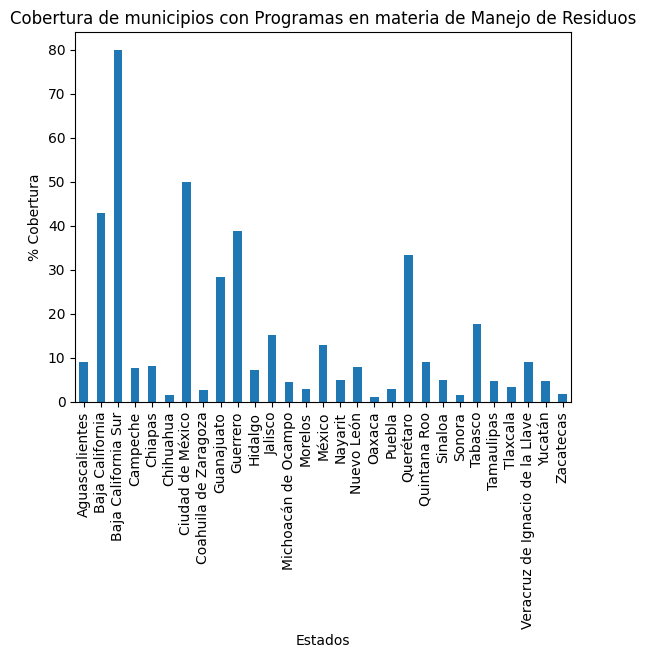

In [667]:
cobertua_programa.plot(
    kind="bar",
    x="Entidad Federativa",
    y="cobertura_prog_%",
    xlabel="Estados",
    ylabel="% Cobertura",
    title="Cobertura de municipios con Programas en materia de Manejo de Residuos"
)

plt.show()

In [668]:
porcentaje.describe()

,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,total_municipios,programas_estado,cobertura_prog_%
count,180.0,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.0,0.277778,0.722222,113.616667,14.788889,20.551726
std,0.0,0.449153,0.449153,103.961224,10.414316,17.234781
min,1.0,0.000000,0.000000,5.000000,1.000000,1.052632
25%,1.0,0.000000,0.000000,46.000000,6.000000,8.064516
50%,1.0,0.000000,1.000000,85.000000,13.000000,12.800000
75%,1.0,1.000000,1.000000,125.000000,19.000000,38.823529
max,1.0,1.000000,1.000000,570.000000,33.000000,80.000000


In [669]:
print(porcentaje[porcentaje["programas_estado"]==1])

       Entidad Federativa Municipio/ Demarcación territorial  \
0          Aguascalientes                     Aguascalientes   
8                Campeche                          Escárcega   
9    Coahuila de Zaragoza                              Acuña   
20              Chihuahua                          Chihuahua   
121               Morelos                            Temixco   
122               Nayarit                              Tepic   
145          Quintana Roo                      Benito Juárez   
146               Sinaloa                              Elota   
147                Sonora                         Hermosillo   
179             Zacatecas                          Zacatecas   

     Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos  \
0                                                    1                                                
8                                                    1                                   

### Baja California, BJS, Ciudadde México, Guerrero, Querétaro, son los Estados que más municipios tienen un Programa en materia de gestión de residuos. BCS 4 de sus 5 municipios, Guerrero 33 de 85, CDMX con 8 de 16 Alcaldías.
### Oaxaca el estado con mayor cantidad de municipios, registra apenas 6 municipios con programa de 570, puebla 6 de 217, Veracruz con 19 de 212, Jalisco 19 de 125.

### Guerrero es el Estado que mayor número de programas presenta mientras que Aguascalientes, campeche, Coahuila, Chihuahua, Morelos, Nayarit, Quintana Roo, Sinaloa, Sonora y Zacatecas presentan un solo programa. 

### En la primera parte, se determinó que los RSU recolectado en todo México para 2022 (etiquetado como 2023) fue de 108,146 Toneladas, de las cuales cierta cantidad puede ir a estaciones de tranferencia donde los RSU  se traspasan de las unidades de recolección a vehículos de mayor capacidad, para su traslado. Algunas estaciones de transferencia cuentan con procesos de separación. Posteriormente los RSU pueden ir a plantas de tratamiento y finalmente a sitios de disposición.

### El objetivo del siguiente apartado es determinar de las 108,146 Toneladas recolectadas que cantidad y/o % se separa en estaciones de trasnferencia, que % se va a tratamiento y que % finalmente se lleva a disposición final. El objetivo es ver el panorama de separacióny reciclaje posterior a la recolección.

### 7.- Estaciones de Transferencia

In [670]:
et.columns = et.columns.str.replace("\n", " ", regex=True).str.strip()
et.info()

<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Entidad federativa                                                     2475 non-null   str    
 1   Municipio/ Demarcación territorial                                     2475 non-null   str    
 2   Estaciones de transferencia con función de separación de materiales 1  112 non-null    float64
 3   Cantidad promedio diaria de materiales clasificados (kilogramos)       42 non-null     object 
dtypes: float64(1), object(1), str(2)
memory usage: 77.5+ KB


In [671]:
et["Entidad federativa"].nunique()

32

In [672]:
et.isnull().sum()

Entidad federativa                                                          0
Municipio/ Demarcación territorial                                          0
Estaciones de transferencia con función de separación de materiales 1    2363
Cantidad promedio diaria de materiales clasificados (kilogramos)         2433
dtype: int64

In [673]:
et = et.rename(columns={"Entidad federativa": "Entidad Federativa"})

et.info()

<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Entidad Federativa                                                     2475 non-null   str    
 1   Municipio/ Demarcación territorial                                     2475 non-null   str    
 2   Estaciones de transferencia con función de separación de materiales 1  112 non-null    float64
 3   Cantidad promedio diaria de materiales clasificados (kilogramos)       42 non-null     object 
dtypes: float64(1), object(1), str(2)
memory usage: 77.5+ KB


In [674]:
et["Entidad Federativa"].nunique()

32

In [675]:
et["Cantidad promedio diaria de materiales clasificados (kilogramos)"] = (
    pd.to_numeric(
        et["Cantidad promedio diaria de materiales clasificados (kilogramos)"],
        errors="coerce"
    ).fillna(0).astype(int)
)

et.sample(5)

,Entidad Federativa,Municipio/ Demarcación territorial,Estaciones de transferencia con función de separación de materiales 1,Cantidad promedio diaria de materiales clasificados (kilogramos)
1759,Puebla,Tianguismanalco,NaN,0
60,Coahuila de Zaragoza,Piedras Negras,NaN,0
1612,Puebla,Camocuautla,NaN,0
1881,San Luis Potosí,Villa Hidalgo,NaN,0
433,Guerrero,Teloloapan,NaN,0


In [676]:
et["Cantidad promedio diaria de materiales clasificados (kilogramos)"]= et["Cantidad promedio diaria de materiales clasificados (kilogramos)"].astype(int)

et.info()

<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Entidad Federativa                                                     2475 non-null   str    
 1   Municipio/ Demarcación territorial                                     2475 non-null   str    
 2   Estaciones de transferencia con función de separación de materiales 1  112 non-null    float64
 3   Cantidad promedio diaria de materiales clasificados (kilogramos)       2475 non-null   int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 77.5 KB


In [677]:
et_estado= et.groupby("Entidad Federativa")["Cantidad promedio diaria de materiales clasificados (kilogramos)"].sum().reset_index()
print(et_estado)

                 Entidad Federativa  \
0                    Aguascalientes   
1                   Baja California   
2               Baja California Sur   
3                          Campeche   
4                           Chiapas   
5                         Chihuahua   
6                  Ciudad de México   
7              Coahuila de Zaragoza   
8                            Colima   
9                           Durango   
10                       Guanajuato   
11                         Guerrero   
12                          Hidalgo   
13                          Jalisco   
14              Michoacán de Ocampo   
15                          Morelos   
16                           México   
17                          Nayarit   
18                       Nuevo León   
19                           Oaxaca   
20                           Puebla   
21                        Querétaro   
22                     Quintana Roo   
23                  San Luis Potosí   
24                       

In [678]:
et_estado.sample(32)

,Entidad Federativa,Cantidad promedio diaria de materiales clasificados (kilogramos)
14,Michoacán de Ocampo,50
7,Coahuila de Zaragoza,0
17,Nayarit,0
8,Colima,0
12,Hidalgo,11086
28,Tlaxcala,0
15,Morelos,2940
5,Chihuahua,0
6,Ciudad de México,1084100
31,Zacatecas,0


### 8.- Total Tratado

In [679]:
pt.columns = pt.columns.str.replace("\n", " ", regex=True).str.strip()
pt.info()

<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column                                                                       Non-Null Count  Dtype 
---  ------                                                                       --------------  ----- 
 0   Entidad federativa                                                           2475 non-null   str   
 1   Municipio/ Demarcación territorial                                           2475 non-null   str   
 2   Cantidad promedio diaria de residuos enviados a planta de tratamiento        2298 non-null   object
 3   Cantidad promedio diaria de materiales recuperados en planta de tratamiento  47 non-null     object
dtypes: object(2), str(2)
memory usage: 77.5+ KB


In [680]:
pt = pt.rename(columns={"Entidad federativa": "Entidad Federativa"})

In [681]:
pt.isnull().sum()

Entidad Federativa                                                                0
Municipio/ Demarcación territorial                                                0
Cantidad promedio diaria de residuos enviados a planta de tratamiento           177
Cantidad promedio diaria de materiales recuperados en planta de tratamiento    2428
dtype: int64

In [682]:
pt["Cantidad promedio diaria de residuos enviados a planta de tratamiento"] = (
    pd.to_numeric(
        pt["Cantidad promedio diaria de residuos enviados a planta de tratamiento"],
        errors="coerce"
    ).fillna(0).astype(int)
)

pt.sample(5)

,Entidad Federativa,Municipio/ Demarcación territorial,Cantidad promedio diaria de residuos enviados a planta de tratamiento,Cantidad promedio diaria de materiales recuperados en planta de tratamiento
284,Ciudad de México,Tláhuac,0,NaN
1291,Oaxaca,Villa Sola de Vega,0,NaN
2445,Zacatecas,Miguel Auza,0,NaN
1382,Oaxaca,Santa Catarina Minas,0,NaN
579,Jalisco,Encarnación de Díaz,0,NaN


In [683]:
pt.sample(5)

,Entidad Federativa,Municipio/ Demarcación territorial,Cantidad promedio diaria de residuos enviados a planta de tratamiento,Cantidad promedio diaria de materiales recuperados en planta de tratamiento
960,Nayarit,Tepic,0,NaN
374,Guanajuato,Xichú,0,NaN
1262,Oaxaca,San Mateo del Mar,0,NaN
90,Chiapas,Amatenango del Valle,0,NaN
939,Morelos,Zacualpan de Amilpas,0,NaN


In [684]:
pt.info()

<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column                                                                       Non-Null Count  Dtype 
---  ------                                                                       --------------  ----- 
 0   Entidad Federativa                                                           2475 non-null   str   
 1   Municipio/ Demarcación territorial                                           2475 non-null   str   
 2   Cantidad promedio diaria de residuos enviados a planta de tratamiento        2475 non-null   int64 
 3   Cantidad promedio diaria de materiales recuperados en planta de tratamiento  47 non-null     object
dtypes: int64(1), object(1), str(2)
memory usage: 77.5+ KB


In [685]:

pt["Entidad Federativa"].nunique()

32

In [686]:
pt_estado= pt.groupby("Entidad Federativa")["Cantidad promedio diaria de residuos enviados a planta de tratamiento"].sum().reset_index()
pt_estado.sample(5)

,Entidad Federativa,Cantidad promedio diaria de residuos enviados a planta de tratamiento
21,Querétaro,384020
30,Yucatán,114270
1,Baja California,0
5,Chihuahua,231500
26,Tabasco,205000


In [687]:
porcentaje.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Entidad Federativa                                                                              180 non-null    str    
 1   Municipio/ Demarcación territorial                                                              180 non-null    str    
 2   Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos  180 non-null    int64  
 3   Tipo de programa PMPGIRSU 1                                                                     180 non-null    float64
 4   Tipo de programa Otro                                                                           180 non-null    float64
 5   total_municipios           

In [688]:
porcentaje.sample(3)

,Entidad Federativa,Municipio/ Demarcación territorial,Municipios o demarcaciones territoriales con programas orientados a la gestión de los residuos,Tipo de programa PMPGIRSU 1,Tipo de programa Otro,total_municipios,programas_estado,cobertura_prog_%
8,Campeche,Escárcega,1,1.0,0.0,13,1,7.692308
69,Guerrero,Tlapehuala,1,0.0,1.0,85,33,38.823529
155,Veracruz de Ignacio de la Llave,Carrillo Puerto,1,0.0,1.0,212,19,8.962264


In [689]:
# información acerca de recolección diaria x estado
df2022=df_recolectados[df_recolectados["año"]==2023]

inf2022=df2022.groupby("Entidad Federativa")["Cantidad promedio diaria de residuos sólidos urbanos recolectados"].sum().reset_index()
inf2022.sample(5)

,Entidad Federativa,Cantidad promedio diaria de residuos sólidos urbanos recolectados
26,Tabasco,1.798134
24,Sinaloa,3.439029
21,Querétaro,1.658680
17,Nayarit,1.829902
31,Zacatecas,1.340570


In [690]:
# empezar hacer los merge de RSU recolectados con estaciones de trasnferencia
trazabilidad_residuos=inf2022.merge(et_estado, on="Entidad Federativa")

trazabilidad_residuos.sample(5)

,Entidad Federativa,Cantidad promedio diaria de residuos sólidos urbanos recolectados,Cantidad promedio diaria de materiales clasificados (kilogramos)
30,Yucatán,1.886875,0
24,Sinaloa,3.439029,0
22,Quintana Roo,3.013873,0
3,Campeche,0.740250,0
13,Jalisco,8.814589,8282


In [691]:
trazabilidad_residuos=trazabilidad_residuos.merge(pt_estado, on="Entidad Federativa")
trazabilidad_residuos.sample(5)

,Entidad Federativa,Cantidad promedio diaria de residuos sólidos urbanos recolectados,Cantidad promedio diaria de materiales clasificados (kilogramos),Cantidad promedio diaria de residuos enviados a planta de tratamiento
30,Yucatán,1.886875,0,114270
29,Veracruz de Ignacio de la Llave,5.486834,285,163800
4,Chiapas,3.263688,40000,4120
10,Guanajuato,4.549696,0,40000
7,Coahuila de Zaragoza,2.612453,0,0


In [692]:
trazabilidad_residuos["total_recolectados"]=(trazabilidad_residuos["Cantidad promedio diaria de residuos sólidos urbanos recolectados"])*1000  # anteriormente los habia convertido a miles de Ton, ahora los pase a Ton
trazabilidad_residuos["total Cantidad_enviados_ET"]=(trazabilidad_residuos["Cantidad promedio diaria de materiales clasificados (kilogramos)"])/1000 # divido para los kg convertirlos a Ton
trazabilidad_residuos["total Cantidad_enviados_PT"]=(trazabilidad_residuos["Cantidad promedio diaria de residuos enviados a planta de tratamiento"])/1000 # divido para los kg convertirlos a Ton
trazabilidad_residuos["total Cantidad_enviados_DP"]=trazabilidad_residuos["total_recolectados"]-trazabilidad_residuos["total Cantidad_enviados_ET"]- trazabilidad_residuos["total Cantidad_enviados_PT"]
trazabilidad_residuos.sample(3)

,Entidad Federativa,Cantidad promedio diaria de residuos sólidos urbanos recolectados,Cantidad promedio diaria de materiales clasificados (kilogramos),Cantidad promedio diaria de residuos enviados a planta de tratamiento,total_recolectados,total Cantidad_enviados_ET,total Cantidad_enviados_PT,total Cantidad_enviados_DP
20,Puebla,3.926876,1185,100713,3926.876,1.185,100.713,3824.978
17,Nayarit,1.829902,0,6000,1829.902,0.000,6.000,1823.902
24,Sinaloa,3.439029,0,0,3439.029,0.000,0.000,3439.029


In [693]:
print(trazabilidad_residuos["total_recolectados"].sum()) #total nacional recolectados
 
print(trazabilidad_residuos["total Cantidad_enviados_ET"].sum()) #total nacional estaciones transferencia



108146.271
1253.9599999999998


In [694]:
# considerando que los RSU que se van a ET el 100% se reciclao recupera e igualmente enlas plantas de tratamiento

porcentaje_rsu_DP = (
    trazabilidad_residuos["total Cantidad_enviados_DP"].sum() 
    / trazabilidad_residuos["total_recolectados"].sum()
) * 100

print(f"De todos los RSU, el {porcentaje_rsu_DP:.2f}% se fueron directo a DP a rellenos, tiraderos, etc.")



De todos los RSU, el 93.61% se fueron directo a DP a rellenos, tiraderos, etc.


In [695]:
trazabilidad_residuos_2=trazabilidad_residuos[["Entidad Federativa", "total_recolectados", "total Cantidad_enviados_ET", "total Cantidad_enviados_PT", "total Cantidad_enviados_DP"]]

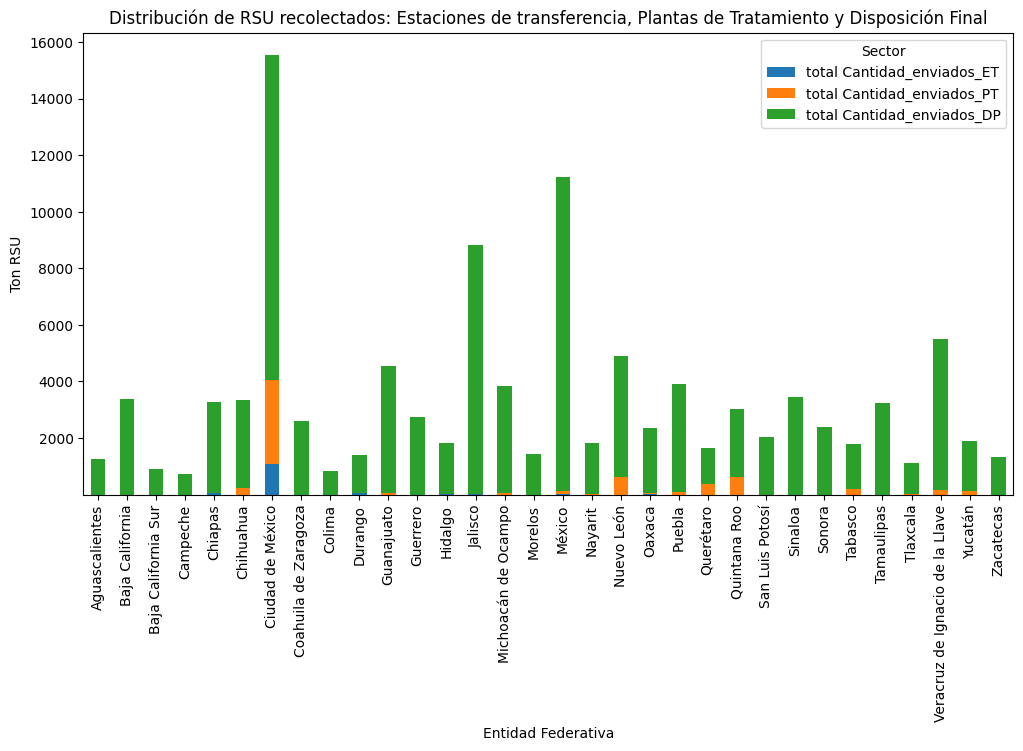

In [696]:

Y = ["total Cantidad_enviados_ET", "total Cantidad_enviados_PT", "total Cantidad_enviados_DP"]

gráfica = trazabilidad_residuos_2.plot(
    kind="bar",
    x="Entidad Federativa",
    y=Y,
    stacked=True,            
    figsize=(12,6),
    title="Distribución de RSU recolectados: Estaciones de transferencia, Plantas de Tratamiento y Disposición Final"
)

plt.ylabel("Ton RSU")
plt.xticks(rotation=90)
plt.legend(title="Sector")



plt.show()





In [697]:
#estados con ET
estados_ET=trazabilidad_residuos[trazabilidad_residuos["total Cantidad_enviados_ET"]>0]
estados_ET["Entidad Federativa"].unique()

<StringArray>
[                        'Chiapas',                'Ciudad de México',
                         'Durango',                         'Hidalgo',
                         'Jalisco',             'Michoacán de Ocampo',
                         'Morelos',                          'México',
                          'Oaxaca',                          'Puebla',
 'Veracruz de Ignacio de la Llave']
Length: 11, dtype: str

In [698]:
# estados con PT

estados_PT=trazabilidad_residuos[trazabilidad_residuos["total Cantidad_enviados_PT"]>0]
estados_PT["Entidad Federativa"].unique()

<StringArray>
[                        'Chiapas',                       'Chihuahua',
                'Ciudad de México',                      'Guanajuato',
                         'Hidalgo',                         'Jalisco',
             'Michoacán de Ocampo',                          'México',
                         'Nayarit',                      'Nuevo León',
                          'Oaxaca',                          'Puebla',
                       'Querétaro',                    'Quintana Roo',
                         'Tabasco',                      'Tamaulipas',
                        'Tlaxcala', 'Veracruz de Ignacio de la Llave',
                         'Yucatán']
Length: 19, dtype: str

### La mayoría de los municipios y estados envian directamente los residuos recolectados a sitios de disposición final (que no necesariamente son rellenos sanitarios), solo 11 estados tienen estaciones de transferencia y 19 cuentan con plantas de tratamiento.


### 9.- Sitios de disposición final

In [699]:
sdf.columns = sdf.columns.str.replace("\n", " ", regex=True).str.strip()
sdf.info()


<class 'pandas.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 3 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Entidad federativa                  2475 non-null   str  
 1   Municipio/ Demarcación territorial  2475 non-null   str  
 2   Sitios de disposición final 1       2475 non-null   int64
dtypes: int64(1), str(2)
memory usage: 58.1 KB


In [700]:
sdf.isnull().sum()

Entidad federativa                    0
Municipio/ Demarcación territorial    0
Sitios de disposición final 1         0
dtype: int64

In [701]:
sdf_estados=sdf.groupby("Entidad federativa")["Sitios de disposición final 1"].sum()
sdf_estados.sample(5)

Entidad federativa
Sonora        116
Sinaloa        48
Yucatán       126
Nuevo León     42
Hidalgo        52
Name: Sitios de disposición final 1, dtype: int64

<Axes: xlabel='Entidad federativa'>

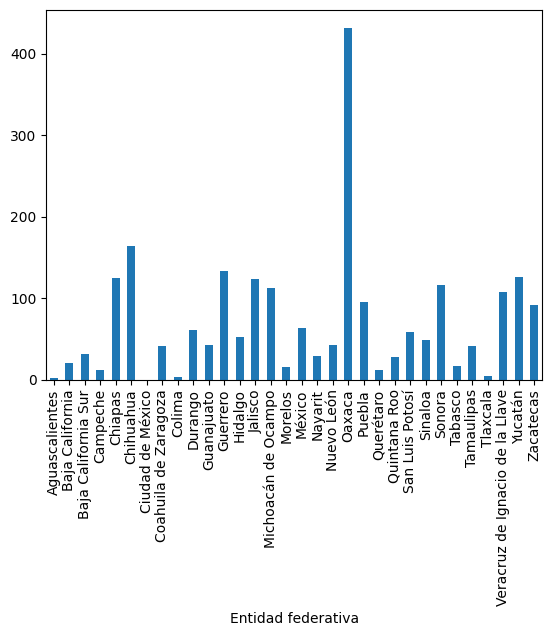

In [702]:
sdf_estados.plot(
    kind="bar"
)